In [10]:
import pandas as pd
from pathlib import Path

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1,'Stage 2': 2,'Stage 3': 3})

stage_groups = clinical_df.groupby('Stage')['Patient ID'].apply(list)
stage_1 = stage_groups.get(1, [])
stage_2 = stage_groups.get(2, [])
stage_3 = stage_groups.get(3, [])

main_path = Path(r"E:\DATA_Myelomy")

def create_stage_df(patient_list):
    all_dfs = []
    for patient_id in patient_list:
        patient_folder = main_path / str(patient_id)

        if patient_folder.exists():
            file_path = next(patient_folder.rglob("*CaSupp_25_radiomics_individual_lesion_features.csv*"), None)

            temp_df = pd.read_csv(file_path)
            temp_df['Patient ID'] = patient_id
            all_dfs.append(temp_df)

    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

df_stage_1 = (create_stage_df(stage_1))
df_stage_2 = (create_stage_df(stage_2))
df_stage_3 = (create_stage_df(stage_3))

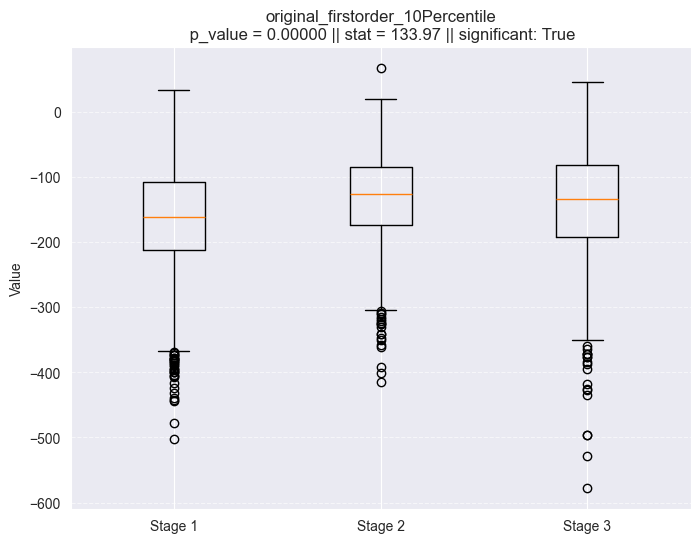

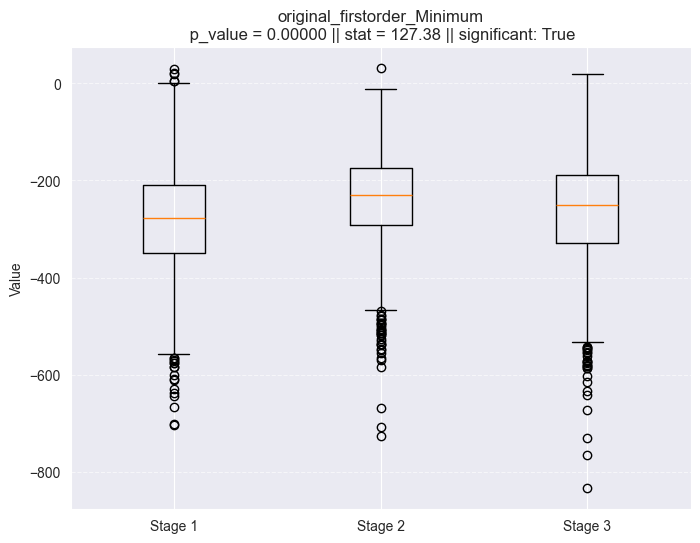

In [11]:
import matplotlib.pyplot as plt

for feature in df_stage_1.select_dtypes(include=['number']).columns:

    data_to_plot = [
        df_stage_1[feature].dropna(),
        df_stage_2[feature].dropna(),
        df_stage_3[feature].dropna()
    ]

    from scipy.stats import kruskal
    stat, p_value = kruskal(df_stage_1[feature].dropna(),  df_stage_2[feature].dropna(), df_stage_3[feature].dropna())

    if stat > 120:
        plt.figure(figsize=(8, 6))
        plt.boxplot(data_to_plot, tick_labels=['Stage 1', 'Stage 2', 'Stage 3'])
        plt.title(f'{feature}\n p_value = {p_value:.5f} || stat = {stat:.2f} || significant: {p_value < 0.05}')
        plt.ylabel('Value')
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()

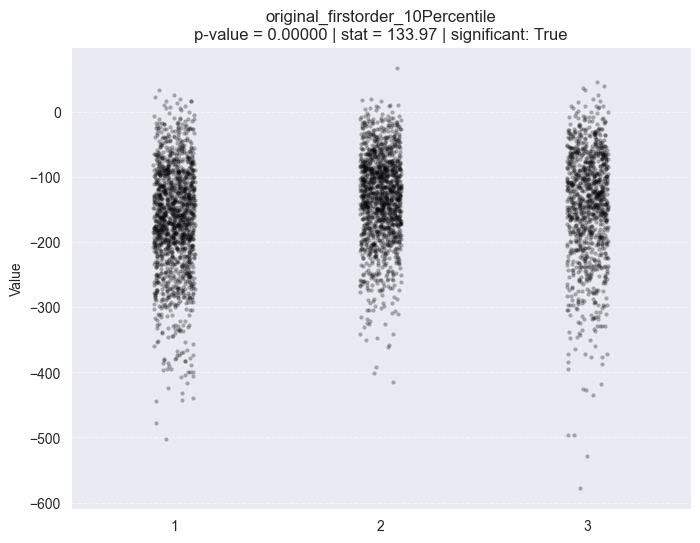

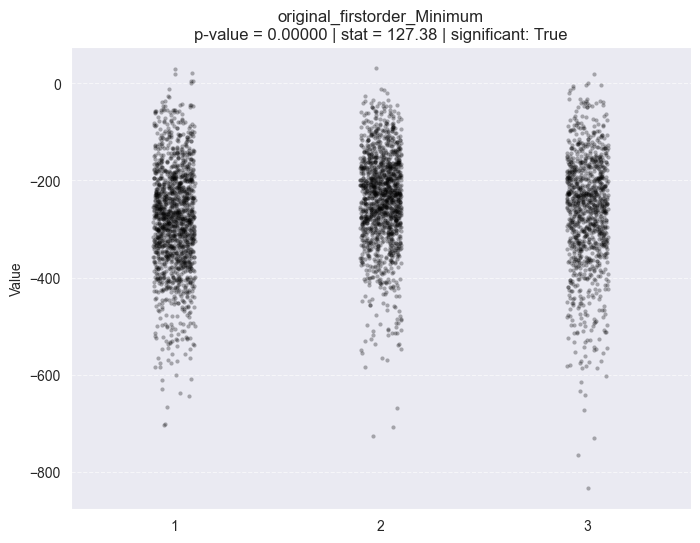

In [12]:
import seaborn as sns

for feature in df_stage_1.select_dtypes(include=['number']).columns:

    s1 = df_stage_1[feature].dropna()
    s2 = df_stage_2[feature].dropna()
    s3 = df_stage_3[feature].dropna()
    data_to_plot = [s1, s2, s3]

    from scipy.stats import kruskal
    stat, p_value = kruskal(s1, s2, s3)

    if stat > 120:
        plt.figure(figsize=(8, 6))
        for i, d in enumerate(data_to_plot, start=1):
            sns.stripplot(x=[i]*len(d), y=d, color='black', alpha=0.3, size=3)

        plt.title(f'{feature}\np-value = {p_value:.5f} | stat = {stat:.2f} | significant: {p_value < 0.05}')
        plt.ylabel('Value')
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()